# Inverse DFT with QEpy: Minimal Reproducible Workflow

This notebook shows a compact inverse-DFT-style loop built on QEpy:

1. Run a reference SCF to obtain a target density $(\rho_{\mathrm{ref}})$
2. Run an iterative SCF workflow with an external correction potential $(v_{\mathrm{corr}})$
3. Update $(v_{\mathrm{corr}})$ so the current density approaches $(\rho_{\mathrm{ref}})$
4. Track convergence with density mismatch and Hartree residual metrics

## Why this example is useful

- Minimal code path for density-level inverse updates
- Direct programmatic access to QE densities and external potential hooks
- Fast enough for notebook experimentation and teaching
- Easy to extend with better update rules (preconditioning, line search, regularization)

## Outputs

- printed convergence history per iteration
- final convergence status and total energy
- `inverse_dft_convergence.pdf` with two diagnostic curves

In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install 'f90wrap<0.2.16' 'qepy' 'dftpy' 'matplotlib'

## 1) Environment check and imports

Import QEpy/DFTpy/NumPy/Matplotlib and print package versions.
If imports fail, install dependencies and ensure QEpy is built against Quantum ESPRESSO.

In [1]:
# Imports and environment check (run this cell first after opening the notebook)
from __future__ import annotations

import importlib.metadata as importlib_metadata
import os
import sys
from pathlib import Path
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

from qepy.driver import Driver
from qepy.io import QEInput
from dftpy.functional import Hartree

## 2) Pseudopotential download and registration

Download `Al_ONCV_PBE-1.2.upf` if missing, validate file presence, and register it for QE input generation.

In [ ]:
#!wget https://www.physics.rutgers.edu/gbrv/al_pbe_v1.uspp.F.UPF #For Linux
!curl "https://www.physics.rutgers.edu/gbrv/al_pbe_v1.uspp.F.UPF" > al_pbe_v1.uspp.F.UPF #For Mac

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 90193  100 90193    0     0   276k      0 --:--:-- --:--:-- --:--:--  276k


## 3) Build reference QE input (`qe_options`)

Define a compact fcc-Al SCF setup:
- one-atom primitive cell
- k-point mesh
- cutoff/smearing settings
- explicit pseudo and scratch directories

In [ ]:
# Paths for QE (forward slashes; avoids issues on Windows and odd working directories)
WORKDIR = "./"
OUTDIR = "./"

# Build common QE options (same XC and pseudo for all runs)
qe_options = {
    "&control": {
        "calculation": "'scf'",
        "pseudo_dir": WORKDIR,
        "outdir": OUTDIR,
    },
    "&system": {
        "ibrav": 0,
        "degauss": 0.01,
        "ecutwfc": 40,
        "nat": 1,
        "ntyp": 1,
        "occupations": "'smearing'",
        "smearing": "'mv'",
    },
    "&electrons": {
        "conv_thr": 1e-8,
    },
    "atomic_positions crystal": ["Al    0.0  0.0  0.0"],
    "atomic_species": [f"Al  26.98 al_pbe_v1.uspp.F.UPF"],
    "k_points automatic": ["4 4 4 0 0 0"],
    "cell_parameters angstrom": [
        "0.     2.025  2.025",
        "2.025  0.     2.025",
        "2.025  2.025  0.   ",
    ],
}

print("Working directory:", WORKDIR)
print("QE scratch: reference ->", OUTDIR)
print("QE input prepared for fcc Al (1 atom cell).")

Working directory: ./
QE scratch: reference -> ./
QE input prepared for fcc Al (1 atom cell).


## 4) Reference SCF: compute target density

Run a standard SCF calculation to generate:
- target density $(\rho_{\mathrm{ref}})$
- reference total energy

This density is the inverse-loop target.

In [3]:
# Step 1: reference SCF calculation -> target density rho_ref
ref_driver = Driver(qe_options=qe_options, logfile="qe_ref.log")
ref_driver.scf()
rho_ref = ref_driver.get_density(gather=True)
energy_ref = ref_driver.get_energy()
print(f"Reference density shape: {rho_ref.shape}")
print(f"Reference PBE total energy (Ry): {energy_ref:.10f}")
ref_driver.stop()

Reference density shape: (13824, 1)
Reference PBE total energy (Ry): -138.3351515379


## 5) Inverse loop with external potential update

Initialize iterative QEpy driver and correction potential $(v_{\mathrm{corr}})$, then iterate:

- set external potential
- recompute density
- evaluate mismatch metrics
- update $(v_{\mathrm{corr}} \leftarrow v_{\mathrm{corr}} + \alpha(\rho - \rho_{\mathrm{ref}}))$

Stop when density error is below tolerance or max iterations is reached.

In [ ]:
# Step 2: inverse-DFT style density matching loop
# We iteratively update an external correction potential v_corr
# so that rho approaches rho_ref.

qe_options_inv = qe_options.copy()
qe_options_inv["&control"] = {**qe_options["&control"],}

#Initialize the inverse-DFT driver
inv_driver = Driver(qe_options=qe_options_inv, iterative=True, logfile="qe_inv.log",)

# Initialize a QEpy density guess
inv_driver.diagonalize()
rho = inv_driver.get_density(gather=True)
v_corr = np.zeros_like(rho, order="F")

max_iter = 300
alpha = 7.0      # simple gradient-like step size
rho_tol = 1e-2   # stopping threshold for 0.5*int|drho|
history = []
converged = False
initial_err = np.abs(inv_driver.data2field(rho_ref - rho)).integral() / 2.0
print(f"[000] initial density error = {initial_err:.6e}")

for it in range(1, max_iter + 1):
    inv_driver.set_external_potential(v_corr, exttype=("xc",), gather=True)
    inv_driver.diagonalize()

    rho = inv_driver.get_density(gather=True)
    drho = rho - rho_ref #Density error at each step
    drho_field = inv_driver.data2field(drho)

    err_l1 = float(np.abs(drho_field).integral() / 2.0)
    err_h = float(Hartree.compute(drho_field).energy) #Hartree error at each step

    # Potential update: v_corr <- v_corr + alpha * (rho - rho_ref)
    v_corr += alpha * drho

    history.append((it, err_l1, err_h))
    print(f"[{it:03d}] 0.5*int|drho|={err_l1:.6e}   EH[drho]={err_h:.6e}")

    if err_l1 < rho_tol:
        converged = True
        break

final_energy = inv_driver.get_energy()
print(f"Converged: {converged} | iterations: {it}")
print(f"Final inverse-loop total energy (Ry): {final_energy:.10f}")

inv_driver.stop()

[000] initial density error = 3.918271e-02
[001] 0.5*int|drho|=4.380726e-01   EH[drho]=7.515973e-02
[002] 0.5*int|drho|=1.897668e-01   EH[drho]=1.230050e-02
[003] 0.5*int|drho|=2.914813e-01   EH[drho]=3.628682e-02
[004] 0.5*int|drho|=2.067230e-01   EH[drho]=1.408478e-02
[005] 0.5*int|drho|=2.275087e-01   EH[drho]=2.327628e-02
[006] 0.5*int|drho|=1.852829e-01   EH[drho]=1.091837e-02
[007] 0.5*int|drho|=1.844426e-01   EH[drho]=1.579718e-02
[008] 0.5*int|drho|=1.574619e-01   EH[drho]=7.633938e-03
[009] 0.5*int|drho|=1.504048e-01   EH[drho]=1.072966e-02
[010] 0.5*int|drho|=1.311197e-01   EH[drho]=5.105166e-03
[011] 0.5*int|drho|=1.224723e-01   EH[drho]=7.214635e-03
[012] 0.5*int|drho|=1.082030e-01   EH[drho]=3.324322e-03
[013] 0.5*int|drho|=9.933193e-02   EH[drho]=4.801922e-03
[014] 0.5*int|drho|=8.884484e-02   EH[drho]=2.122153e-03
[015] 0.5*int|drho|=8.022082e-02   EH[drho]=3.168317e-03
[016] 0.5*int|drho|=7.277372e-02   EH[drho]=1.333008e-03
[017] 0.5*int|drho|=6.451928e-02   EH[drho]=2

## 6) Convergence diagnostics

Plot:
- density mismatch metric $(\frac{1}{2}\int |\Delta\rho|)$
- Hartree residual $(E_H[\Delta\rho])$

and export the figure to `inverse_dft_convergence.pdf`.

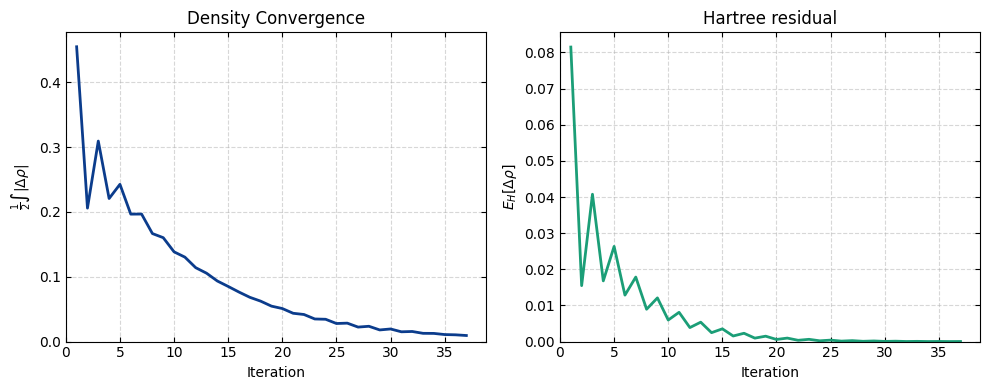

Saved figure: inverse_dft_convergence.pdf


In [25]:
# Step 3: visualize convergence history
h = np.array(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Metric 1: density mismatch
ax1.plot(h[:, 0], h[:, 1], lw=2, color="#0b3c8c")
ax1.set_xlabel("Iteration")
ax1.set_ylabel(r"$\frac{1}{2}\int |\Delta\rho|$")
ax1.set_title("Density Convergence")
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Metric 2: Hartree energy of the density difference
ax2.plot(h[:, 0], h[:, 2], lw=2, color="#1b9e77")
ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$E_H[\Delta\rho]$")
ax2.set_title("Hartree residual")
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)
ax2.grid(True, which="both", ls="--", alpha=0.5)

for ax in (ax1, ax2):
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)

plt.tight_layout()
plt.savefig("inverse_dft_convergence.pdf", dpi=200)
plt.show()

print("Saved figure: inverse_dft_convergence.pdf")

## Notes

- The correction potential update used here is intentionally simple.
- `alpha` controls stability versus speed (too large may oscillate).
- More robust inverse methods may use preconditioning, line search, or regularization.
- The key practical idea is that QEpy gives direct programmatic access to densities and external potentials.